# Week 04 (Module 15) - BBO capstone driver

Round 4. W3 was the weakest round so far (1 new best, 5 misses, 2 confirmed) and surfaced two structural worries:
1. **Local-vs-global lock-in.** PI on f4 dropped 0.54 → 0.44 within 0.003 of the W2 winner — looks like a local-peak shoulder.
2. **Surface steepness.** UCB on f6 and f7 wandered into cliffs (−0.71 → −1.96, 1.69 → 0.05).

**Big additions this round:**
- **NN surrogate** (`bo.NNSurrogate`, small ReLU MLP) — used as a comparison signal, not a replacement for the GP.
- **`acq="far"`** — predicted-value × distance-to-data; favours promising-looking regions we haven't sampled. GP-based.
- **`acq="nn_far"`** — same, but driven by NN extrapolation. The NN sees structure in empty regions where the GP reverts to prior mean.

**Plan, function by function:**
- **f1** → `far` (3 rounds of variance probing in a flat field — change tack to GP-based space-fill).
- **f2** → AEI with bumped xi (more conservative noise threshold).
- **f3** → UCB (still under-mapped at 18 points in 3D).
- **f4** → `nn_far` (NN suggests 2.14 in unmapped territory vs incumbent 0.54 — the brief says many local optima, exactly when not to commit).
- **f5** → variance at a non-corner (peak confirmed deterministic; use slot for geometry).
- **f6** → `nn_far` (NN's far guess −1.05 isn't promising but probes the empty region).
- **f7** → `nn_far` (NN suggests 1.88 in a far region — possible alternative peak).
- **f8** → MES (3 rounds of improvement under MES; don't fix it).


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

# --- settings for this week ---
WEEK = 4
KIND = "matern"
SEED = 0

# Acquisition modes carried forward.
EXPLORE  = dict(acq="ucb", beta=3.0)
BALANCED = dict(acq="ei",  xi=0.01)
OPTIMISE = dict(acq="pi",  xi=0.0)
PROBE    = dict(acq="var")
THOMPSON = dict(acq="thompson")
INFO     = dict(acq="mes")
AUG_EI   = dict(acq="aei", xi=0.05)        # bumped xi this round (was 0.01)
FAR      = dict(acq="far")                 # NEW: GP-based empty-region probe
NN_FAR   = dict(acq="nn_far")              # NEW: NN-driven empty-region probe

# This week's plan: lock-in defence + NN-driven empty-region probes.
PLAN = {}
PLAN[1] = dict(FAR)            # f1 - change tack from variance
PLAN[2] = dict(AUG_EI)         # f2 - AEI with bumped xi
PLAN[3] = dict(EXPLORE)        # f3 - still under-mapped
PLAN[4] = dict(NN_FAR)         # f4 - NN sees a possible bigger peak
PLAN[5] = dict(PROBE)          # f5 - geometry probe; peak confirmed
PLAN[6] = dict(NN_FAR)         # f6 - probe the empty region
PLAN[7] = dict(NN_FAR)         # f7 - NN suggests alternative peak
PLAN[8] = dict(INFO)           # f8 - MES delivering

OUTDIR = f"outputs/week{WEEK:02d}"
os.makedirs(OUTDIR, exist_ok=True)
pd.DataFrame([dict(func=f"f{fid}", **PLAN[fid]) for fid in bo.FUNC_IDS])


,func,acq,xi,beta
0,f1,far,NaN,NaN
1,f2,aei,0.05,NaN
2,f3,ucb,NaN,3.0
3,f4,nn_far,NaN,NaN
4,f5,var,NaN,NaN
5,f6,nn_far,NaN,NaN
6,f7,nn_far,NaN,NaN
7,f8,mes,NaN,NaN


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
results = {fid: bo.run_function(fid, kind=KIND, seed=SEED, **PLAN[fid]) for fid in bo.FUNC_IDS}

summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4),
         pred_std=round(results[fid]["std"], 4),
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary

,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,13,0.0000,-0.0003,0.0010,far,0.005234-0.992655
1,f2,2,13,0.6112,0.2355,0.2145,aei,0.000000-0.896919
2,f3,3,18,-0.0348,-0.0424,0.0496,ucb,0.162030-0.021115-0.512694
3,f4,4,33,0.5401,-16.6239,3.1031,nn_far,0.079149-0.462595-0.687064-0.827588
4,f5,4,23,8662.4050,4687.5164,650.8628,var,0.937179-0.000000-0.000000-0.000000
5,f6,5,23,-0.7048,-1.3736,0.4356,nn_far,0.011375-0.027228-0.046644-0.382212-0.076599
6,f7,6,33,1.6876,0.7738,0.2915,nn_far,0.426860-0.054556-0.475038-0.108300-0.084240-0...
7,f8,8,43,9.9495,9.9496,0.0015,mes,0.121738-0.148931-0.117630-0.213941-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])

,func,ei,ucb,pi,var
0,f1,0.0000,0.0017,0.0000,0.0000
1,f2,0.0019,0.6646,0.0236,0.0460
2,f3,0.0122,0.1064,0.3618,0.0025
3,f4,0.0000,-10.4178,0.0000,9.6290
4,f5,0.0000,5989.2420,0.0000,423622.3412
5,f6,0.0112,-0.5025,0.0596,0.1897
6,f7,0.0001,1.3567,0.0008,0.0849
7,f8,0.0000,9.9525,0.0000,0.0000


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

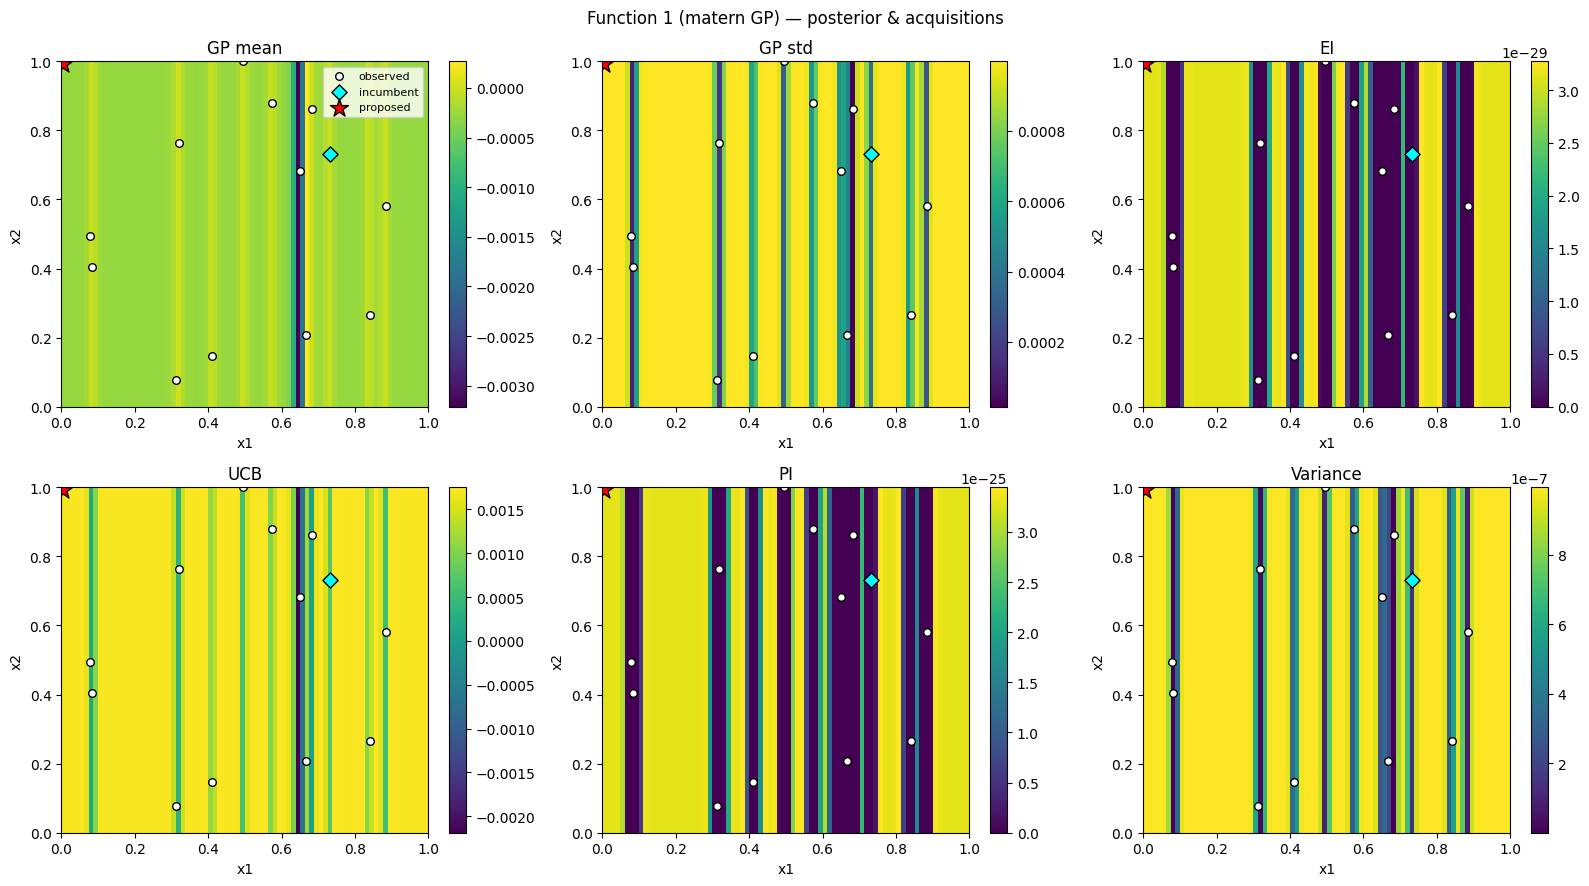

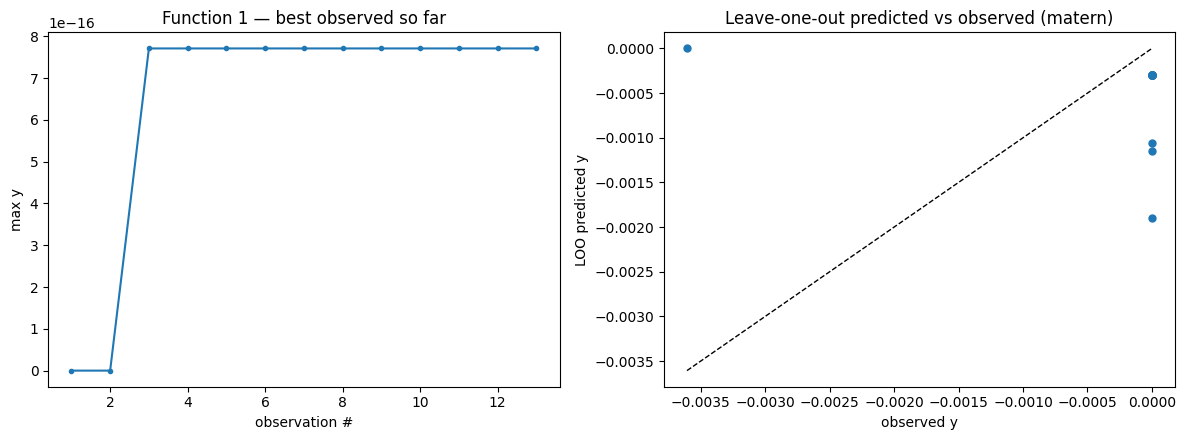

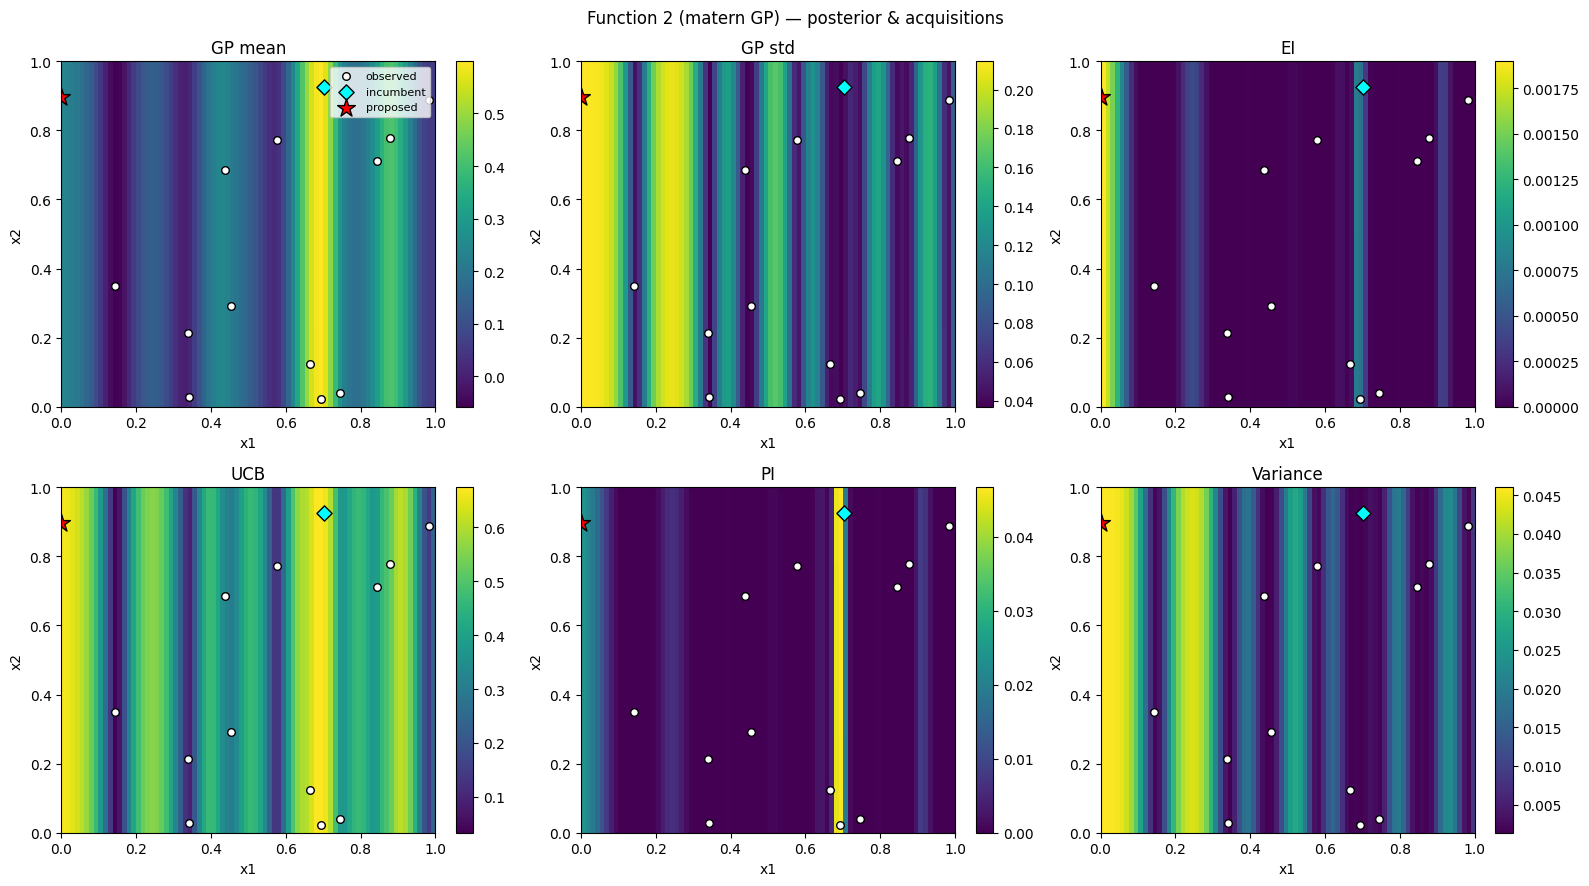

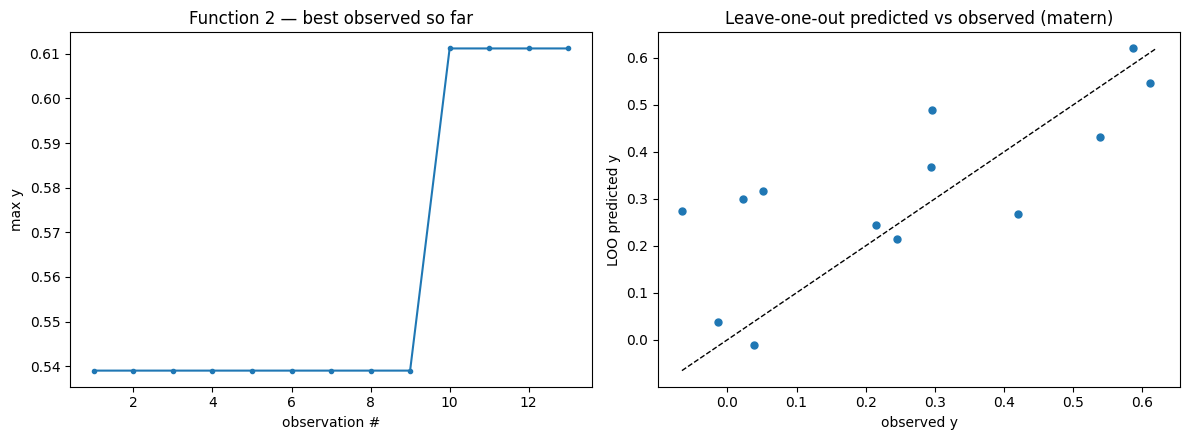

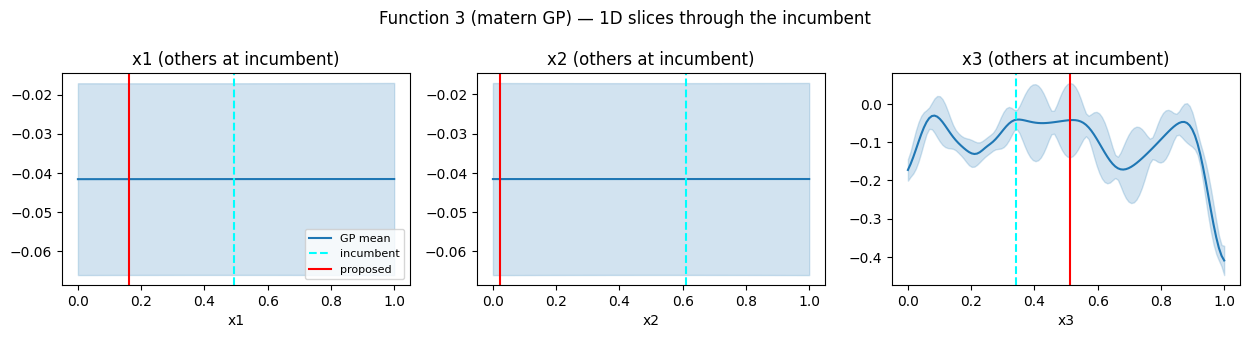

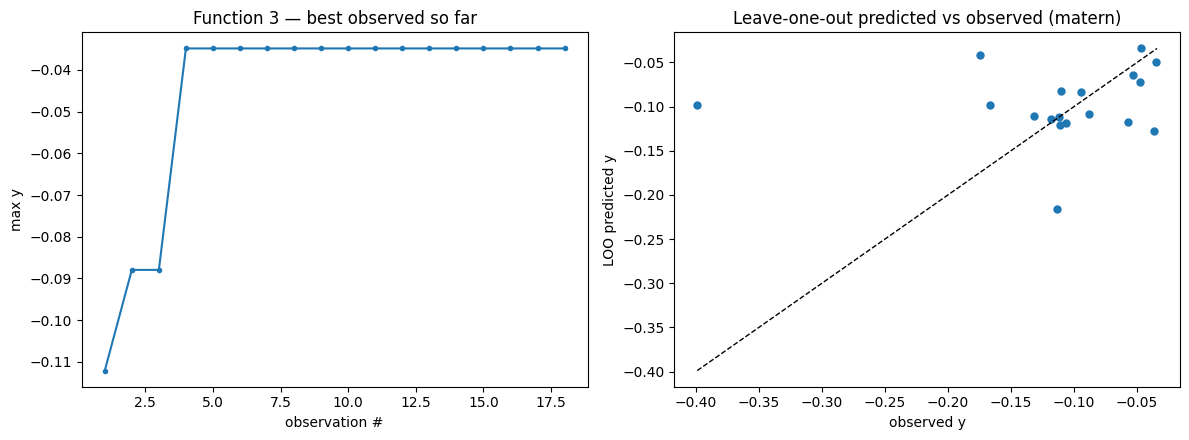

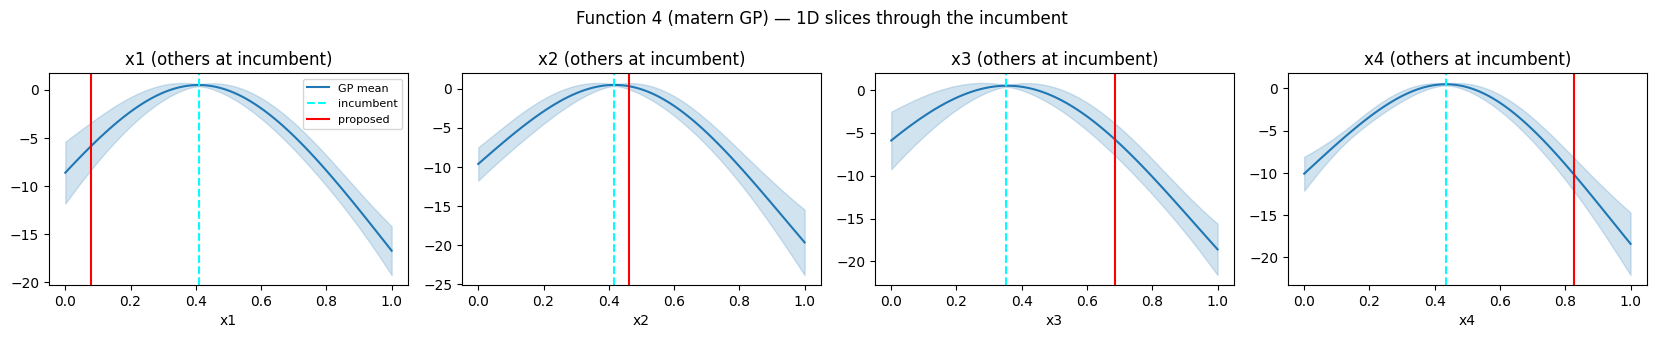

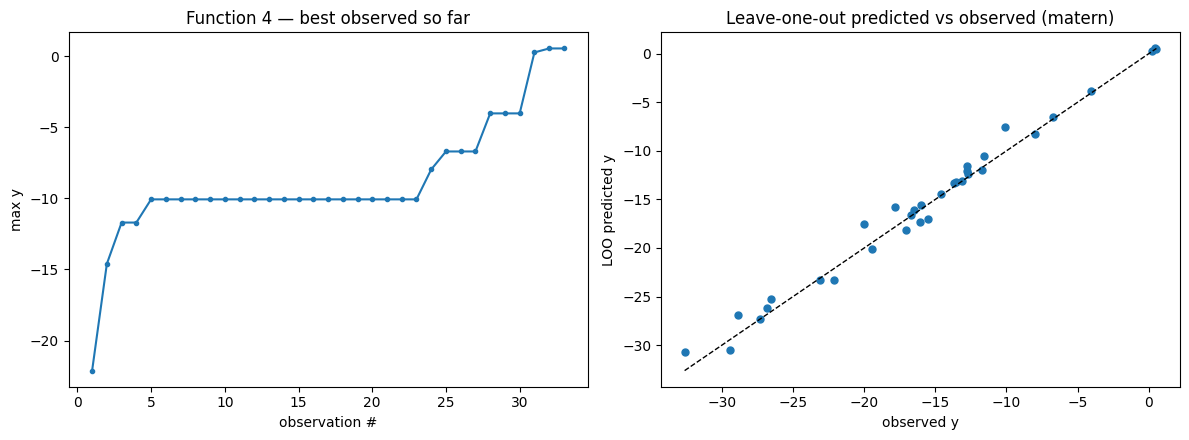

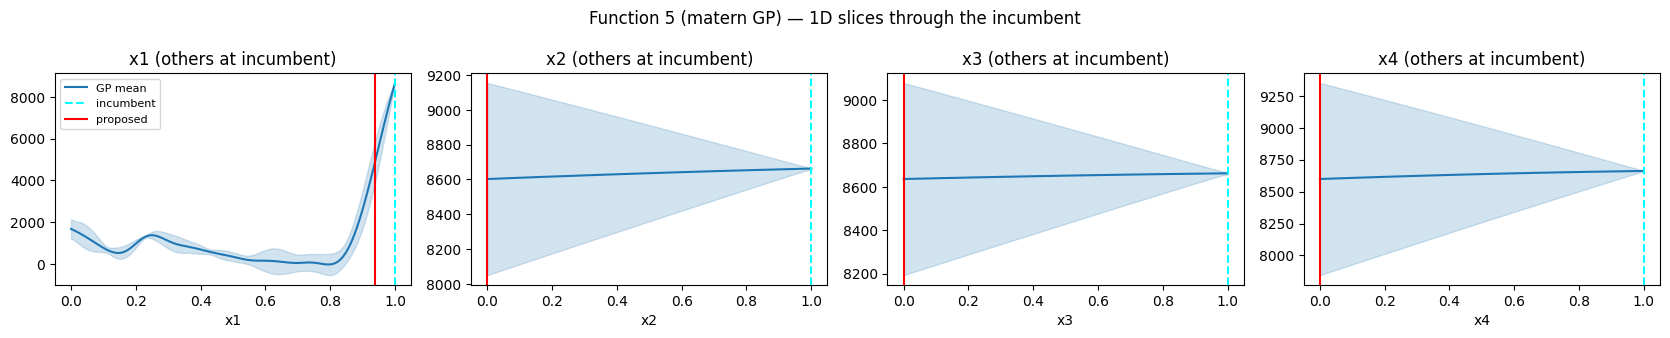

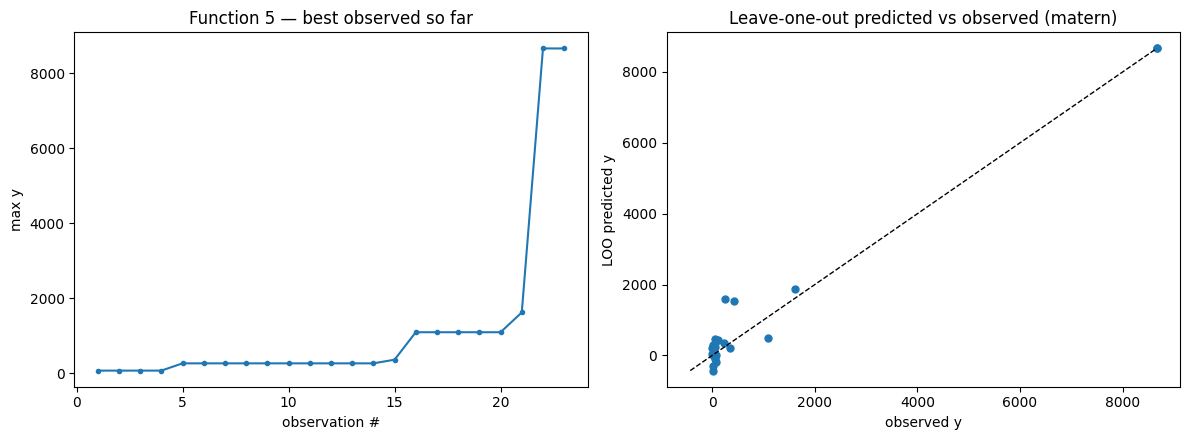

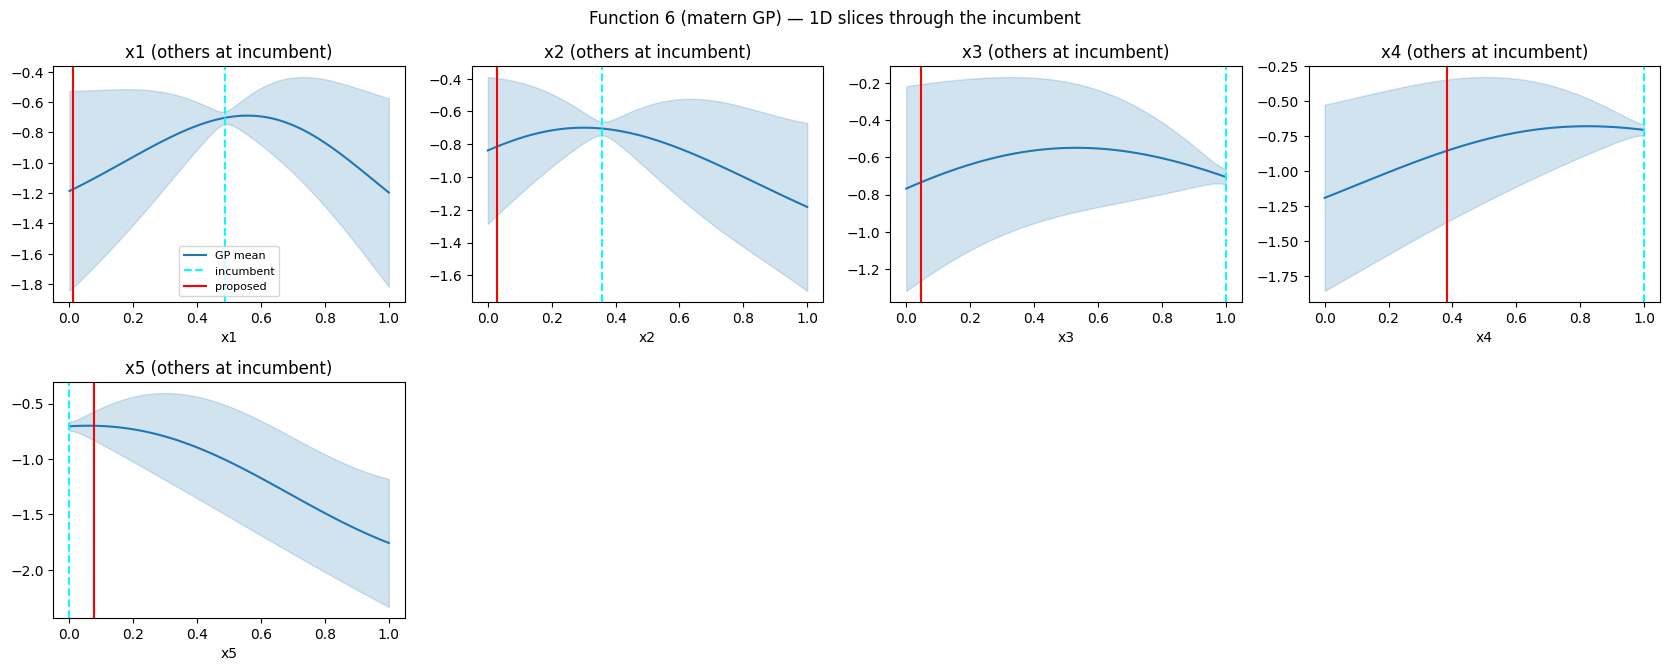

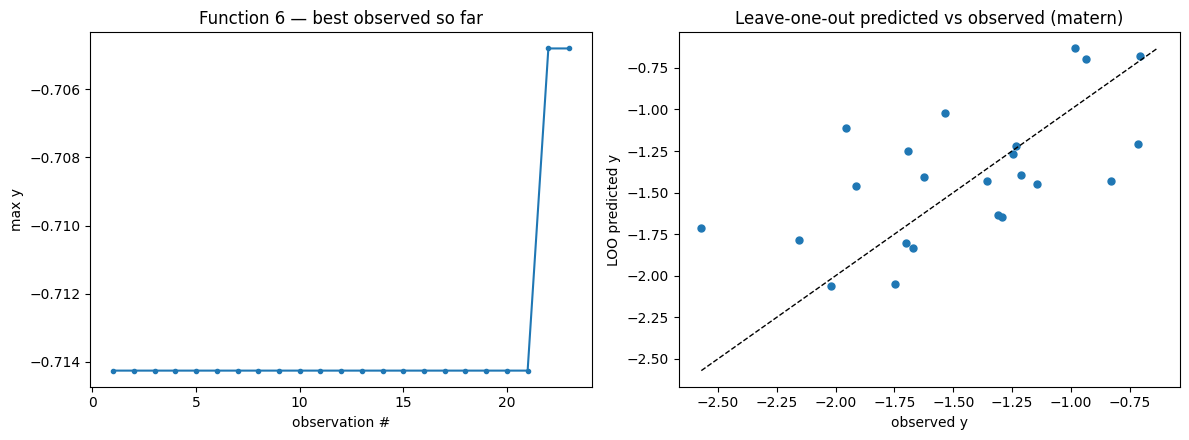

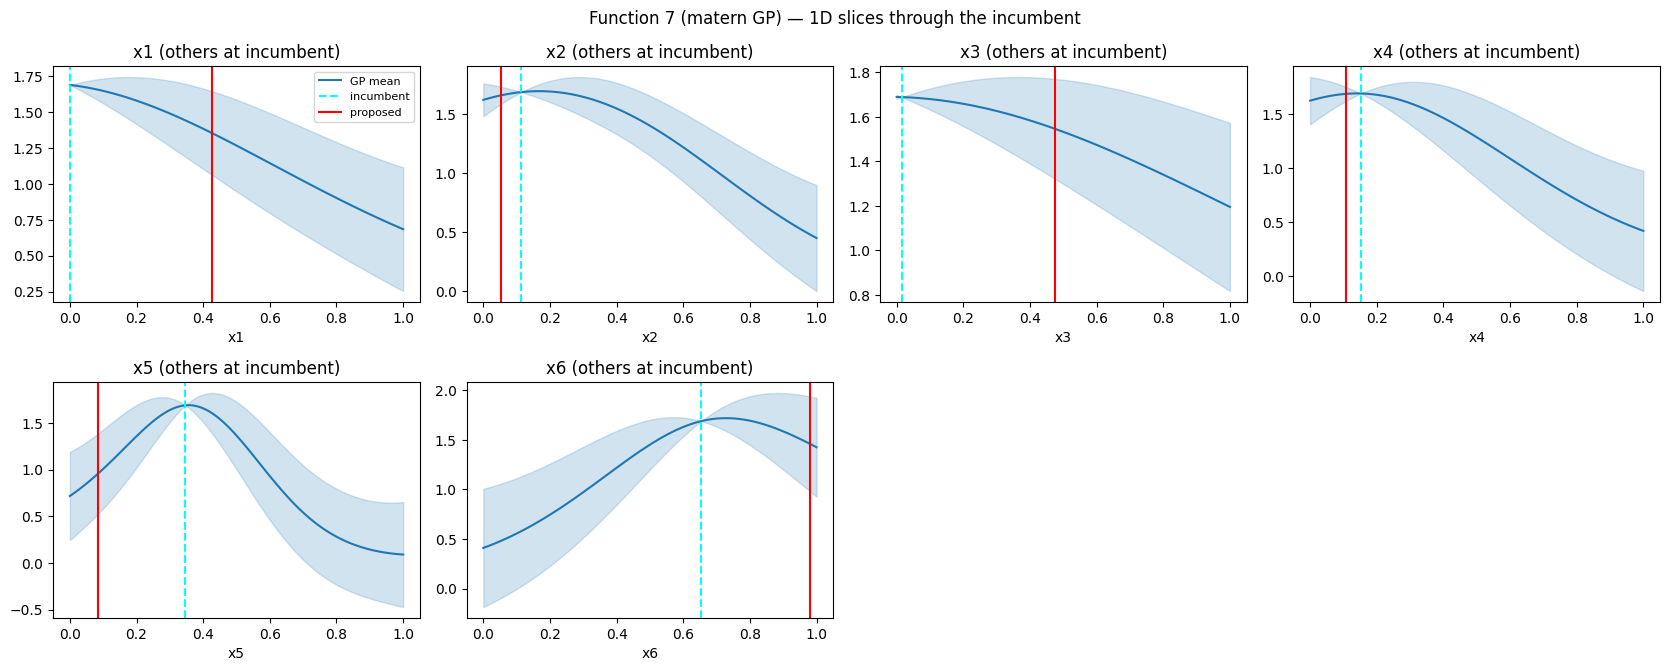

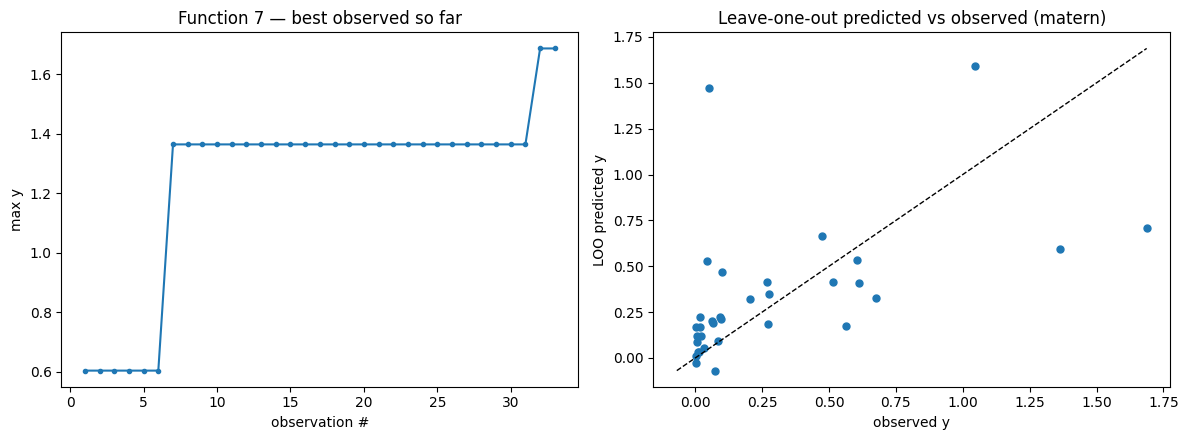

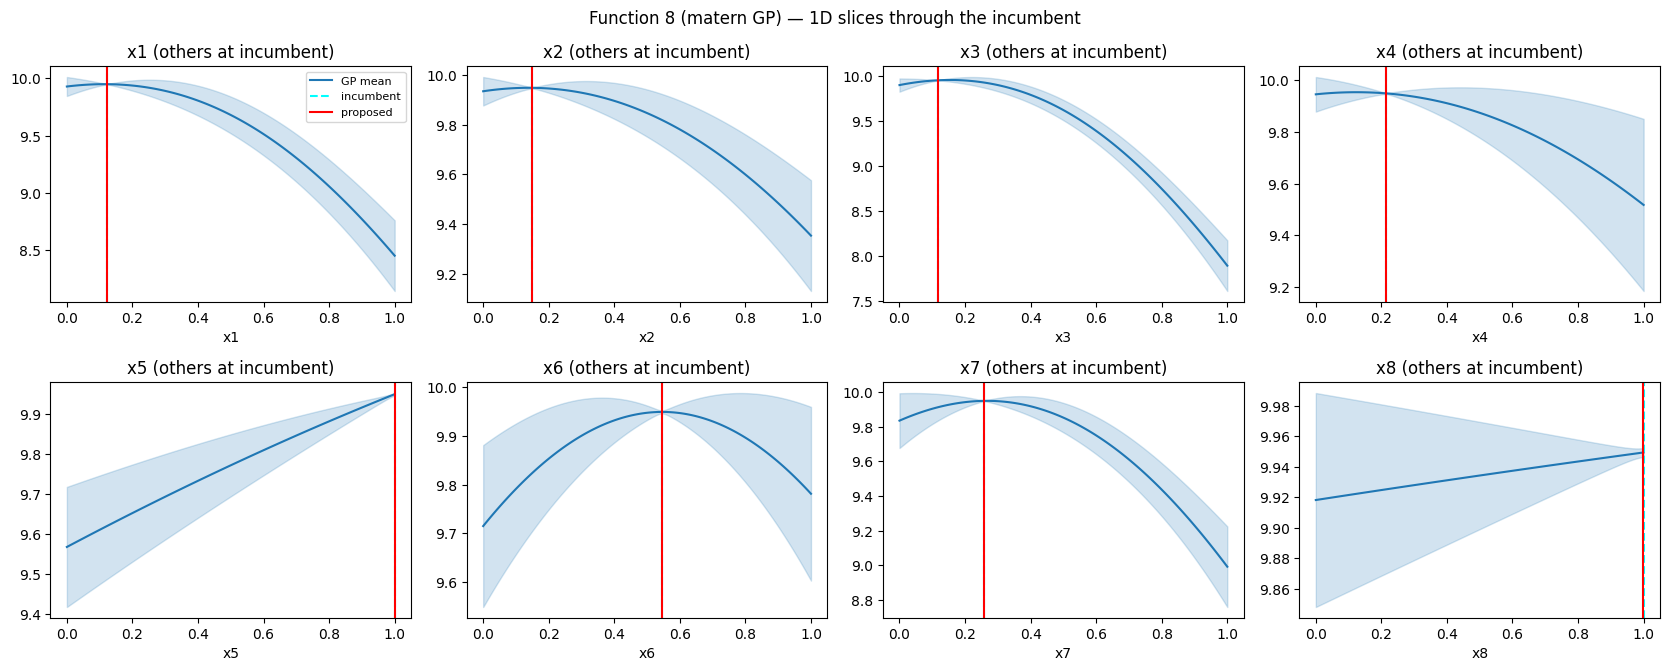

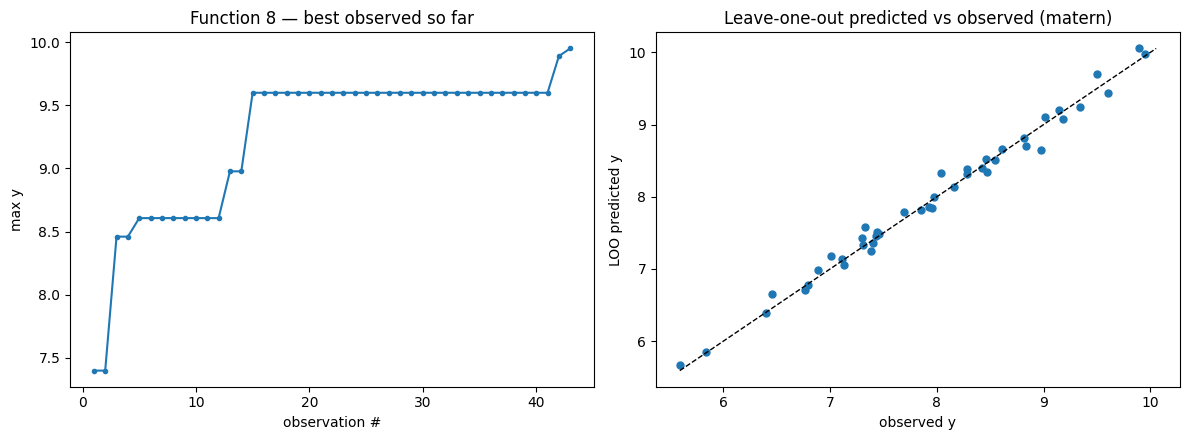

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    beta = PLAN[fid].get("beta", 2.0); xi = PLAN[fid].get("xi", 0.01)
    if m.d == 2:
        bo.plot_2d(m, beta=beta, xi=xi, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, beta=beta, xi=xi, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()

## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.005234-0.992655
f2:  0.000000-0.896919
f3:  0.162030-0.021115-0.512694
f4:  0.079149-0.462595-0.687064-0.827588
f5:  0.937179-0.000000-0.000000-0.000000
f6:  0.011375-0.027228-0.046644-0.382212-0.076599
f7:  0.426860-0.054556-0.475038-0.108300-0.084240-0.981342
f8:  0.121738-0.148931-0.117630-0.213941-0.999999-0.545198-0.258333-0.998119


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)
print("reflection ->", path)

reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week04.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# The scores the portal gave back for week 4's submissions.
# Already saved into data/fN.csv outside the notebook - kept here as a record.
# returned_y = {
#     1: 0.0,
#     2: -0.023638450984096563,
#     3: -0.08569167427688,
#     4: -17.920456320381096,
#     5: 61.82298067418735,
#     6: -1.7653311474732247,
#     7: 0.4388893357355862,
#     8: 9.9498082629714,
# }
# Comparison vs week-3 incumbents:
#   f1 0 (still flat, 4 rounds no signal)               f5 61.82 vs 8662 (var probe; confirms peak is uniquely at corner)
#   f2 -0.024 vs 0.611 (AEI missed again)               f6 -1.77 vs -0.705 (nn_far missed; NN predicted -1.05, close)
#   f3 -0.086 vs -0.035 (UCB missed)                    f7 0.44 vs 1.69 (nn_far missed; NN predicted 1.88 - hallucinated)
#   f4 -17.92 vs 0.54 (NN HALLUCINATED: predicted 2.14)  f8 9.9498 vs 9.95 (MES essentially converged, no movement)
# Net: ZERO new bests. The NN-driven empty-region probes (nn_far on f4, f6, f7) all failed - the NN's extrapolations
# were not signal, they were confident nonsense. The GP's 'I don't know' (reverting to baseline) turned out more honest.
# Key lesson: NN extrapolation in unmapped regions is dangerous at 13-43 sample sizes. Don't trust nn_far again.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
